# Diabetes Prediction using Machine Learning

**Dataset:** Pima Indians Diabetes Database (768 patients, 8 clinical features)
**Goal:** Predict whether a patient is likely to have diabetes, based on diagnostic measurements such as glucose level, BMI, blood pressure, and age.

This dataset was originally collected by the National Institute of Diabetes and Digestive and Kidney Diseases, and is one of the most widely used benchmark datasets in medical machine learning.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, ConfusionMatrixDisplay,
                              RocCurveDisplay)
import joblib

sns.set_theme(style="whitegrid", palette="viridis")
%matplotlib inline


## 1. Load the data

In [3]:
df = pd.read_csv("../data/diabetes_raw.csv")
print(df.shape)
df.head()


(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 2. Data cleaning

Looking at the `.describe()` output above, several columns have a **minimum value of 0** that is medically impossible:
`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` can never truly be zero in a living person.
These zeros are actually **missing values** that were encoded as 0 when the dataset was created.

We'll replace these zeros with `NaN`, then impute them with the **median** of each column (median is more robust to outliers than the mean for skewed medical data).


In [6]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Zero-value counts before cleaning:")
print((df[zero_as_missing] == 0).sum())

for col in zero_as_missing:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

print("\nZero-value counts after cleaning:")
print((df[zero_as_missing] == 0).sum())


Zero-value counts before cleaning:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Zero-value counts after cleaning:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


## 3. Exploratory Data Analysis (EDA)

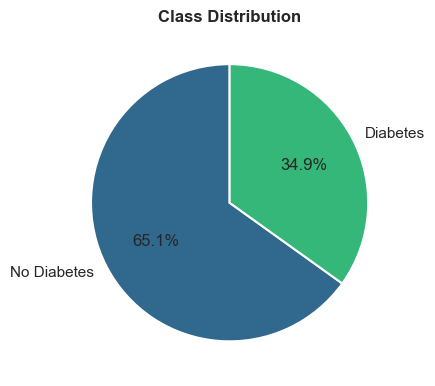

In [7]:
fig, ax = plt.subplots(figsize=(5, 4.5))
counts = df["Outcome"].value_counts().sort_index()
ax.pie(counts, labels=["No Diabetes", "Diabetes"], autopct="%1.1f%%",
       colors=sns.color_palette("viridis", 2), startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Class Distribution", fontweight="bold")
plt.show()


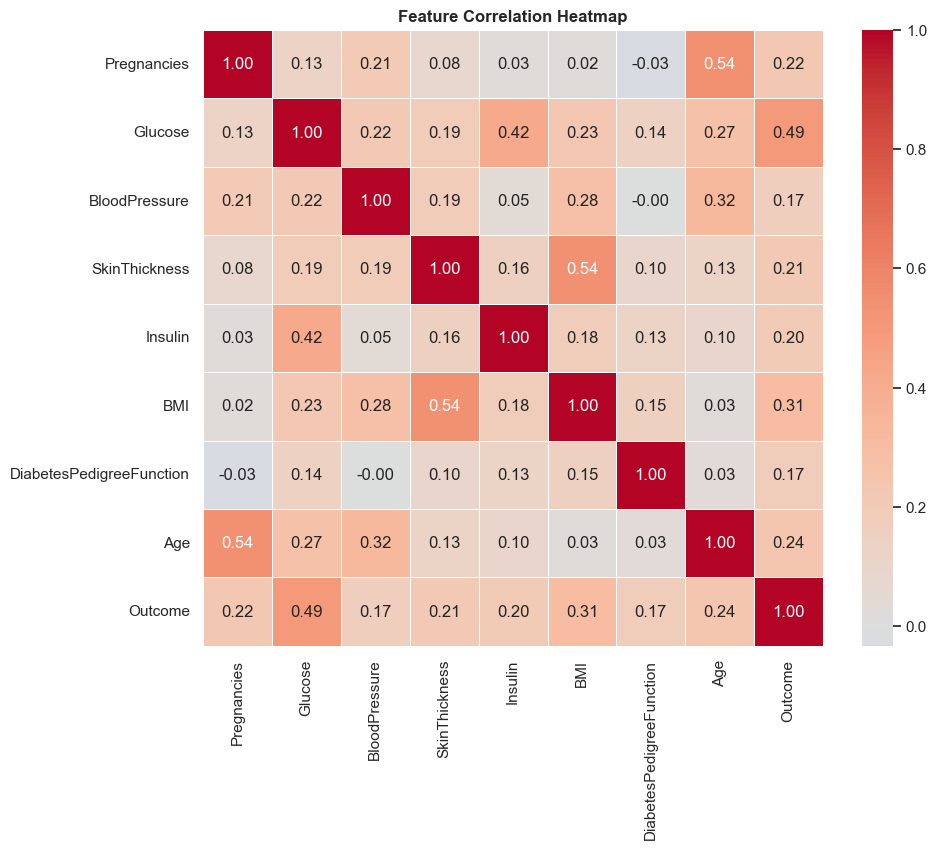

In [8]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontweight="bold")
plt.show()


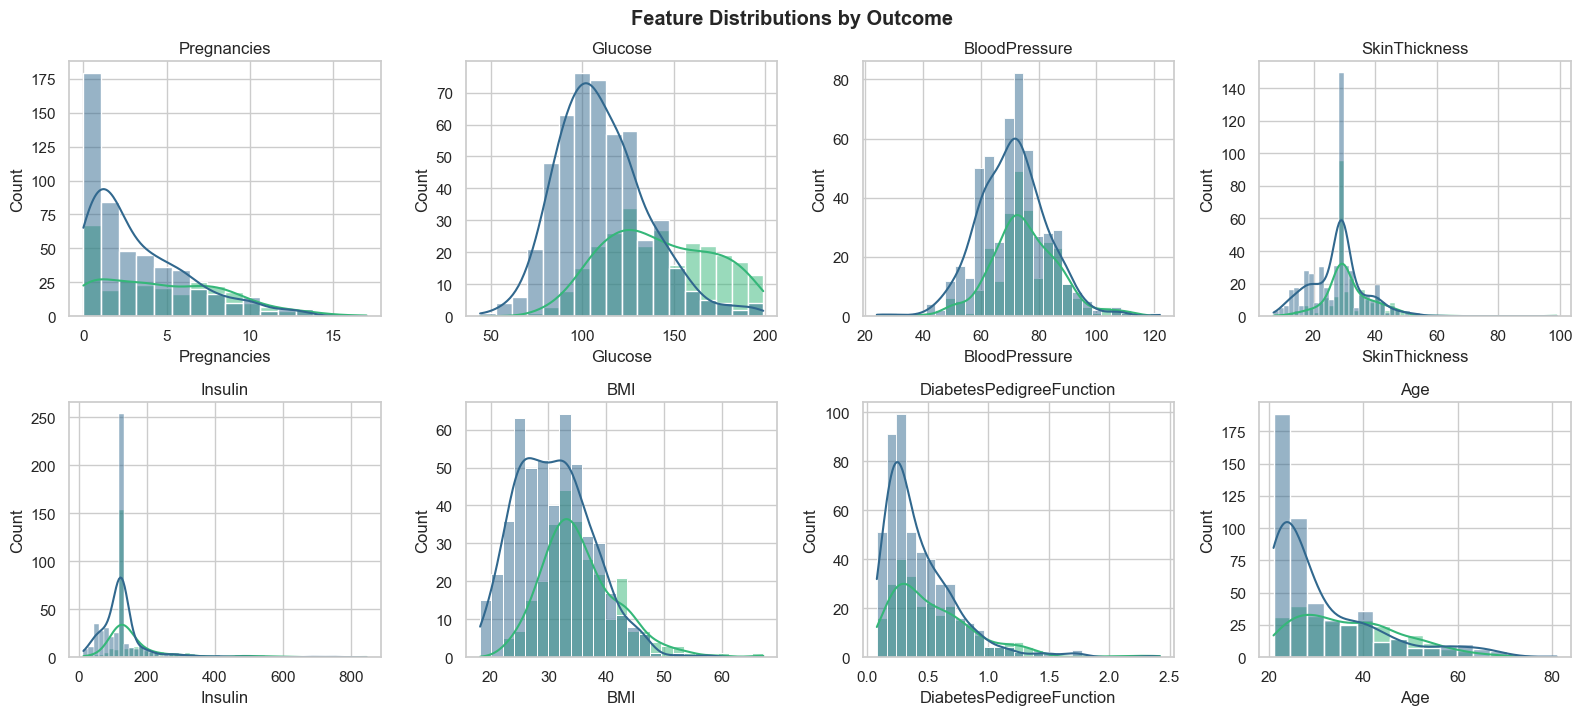

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, df.columns[:-1]):
    sns.histplot(data=df, x=col, hue="Outcome", kde=True, ax=ax, palette="viridis", legend=False)
    ax.set_title(col)
plt.tight_layout()
plt.suptitle("Feature Distributions by Outcome", y=1.02, fontweight="bold")
plt.show()


**Observations:** Patients who developed diabetes tend to skew toward higher `Glucose`, `BMI`, and `Age` — which matches established medical understanding of diabetes risk factors. This is a good sanity check that our data makes clinical sense before we start modeling.

## 4. Train / test split & feature scaling

We hold out 20% of the data purely for *testing* — the models never see this during training, so it gives us an honest estimate of real-world performance.

We also **scale** the features with `StandardScaler` (mean 0, standard deviation 1). This matters a lot for distance-based and margin-based algorithms like KNN and SVM, which are sensitive to features being on different numeric scales (e.g., `Insulin` ranges in the hundreds, `BMI` in the tens).

In [10]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 614, Test size: 154



## The six algorithms we'll compare

| Algorithm | Intuition | Strength |
|---|---|---|
| **Logistic Regression** | Fits a straight "decision boundary" using a weighted sum of features, squashed into a 0–1 probability. | Simple, fast, very interpretable. Good baseline. |
| **Decision Tree** | Asks a series of yes/no questions about feature values to split the data into purer and purer groups. | Easy to visualize; captures non-linear patterns. |
| **Random Forest** | Trains *many* decision trees on random subsets of data/features and averages their votes. | Reduces overfitting vs. a single tree; usually very strong. |
| **K-Nearest Neighbors (KNN)** | Looks at the *k* most similar patients (by feature distance) and takes a majority vote. | No training phase; intuitive "find similar cases" logic. |
| **Support Vector Machine (SVM)** | Finds the boundary that maximizes the margin (gap) between the two classes. | Effective in higher-dimensional feature spaces. |
| **Gradient Boosting** | Builds trees sequentially, where each new tree focuses on correcting the previous trees' mistakes. | Often the most accurate, at the cost of some interpretability. |

We will not just pick one — we'll **train all six, score them fairly on the same held-out test set, and let the data tell us which one wins.**



## How we judge the models

A single "accuracy" number can be misleading for medical data, especially when classes are imbalanced. We track five metrics:

- **Accuracy** — % of all predictions that were correct.
- **Precision** — Of everyone we *predicted* has the disease, what % actually do? (high precision = few false alarms)
- **Recall (Sensitivity)** — Of everyone who *actually* has the disease, what % did we catch? (high recall = few missed cases)
- **F1 Score** — The harmonic mean of precision and recall; a balanced single number.
- **ROC-AUC** — How well the model ranks positive cases above negative cases across *all* possible thresholds (1.0 = perfect, 0.5 = random guessing).

For medical screening tools, **recall is often the most important metric** — missing a sick patient (a false negative) is usually far more costly than a false alarm that gets ruled out with a follow-up test. We'll keep this in mind when picking our final model, not just chase the single highest number.


In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=9),
    "Support Vector Machine": SVC(kernel="rbf", probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1 Score": f1_score(y_test, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.759740,0.688889,0.574074,0.626263,0.830370
1,Random Forest,0.740260,0.652174,0.555556,0.600000,0.816111
2,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
3,Support Vector Machine,0.740260,0.652174,0.555556,0.600000,0.796389
4,K-Nearest Neighbors,0.740260,0.634615,0.611111,0.622642,0.795093
5,Decision Tree,0.759740,0.639344,0.722222,0.678261,0.761019


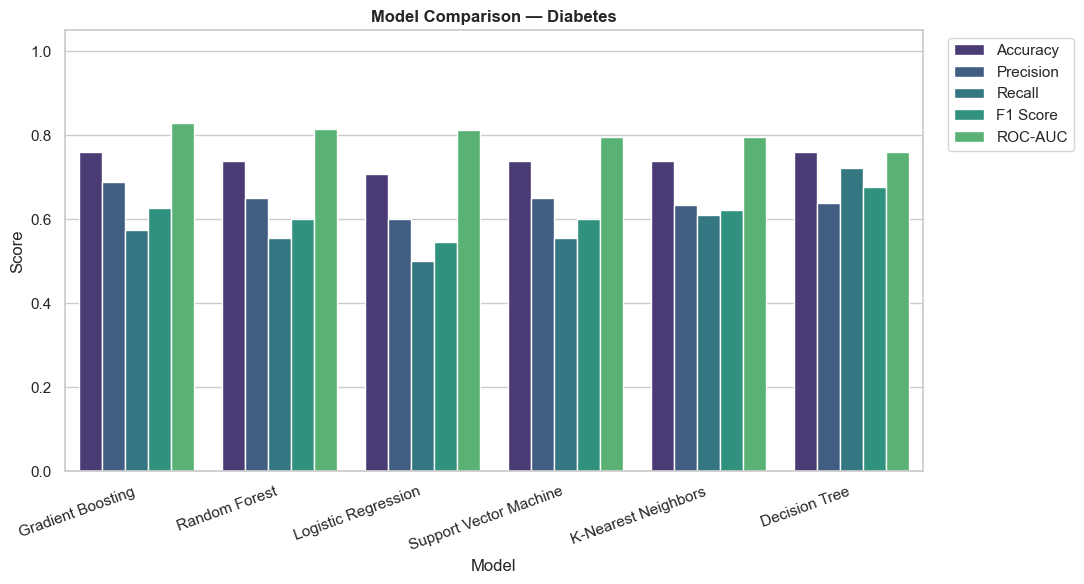

In [12]:
melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(11, 6))
sns.barplot(data=melted, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1.05)
plt.title("Model Comparison — Diabetes", fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 5. Evaluate the best model in detail

Best model: Gradient Boosting


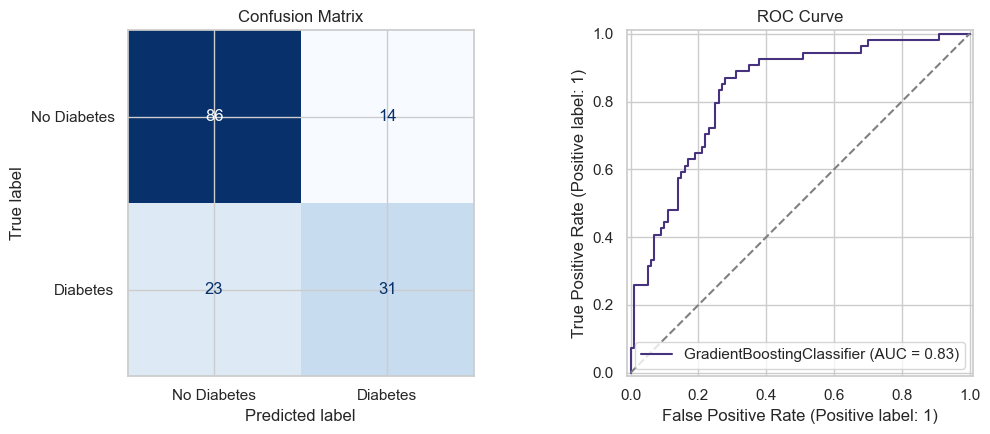

In [13]:
best_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_name]
print(f"Best model: {best_name}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_estimator(best_model, X_test_scaled, y_test,
                                       display_labels=["No Diabetes", "Diabetes"],
                                       cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_estimator(best_model, X_test_scaled, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[1].set_title("ROC Curve")
plt.tight_layout()
plt.show()


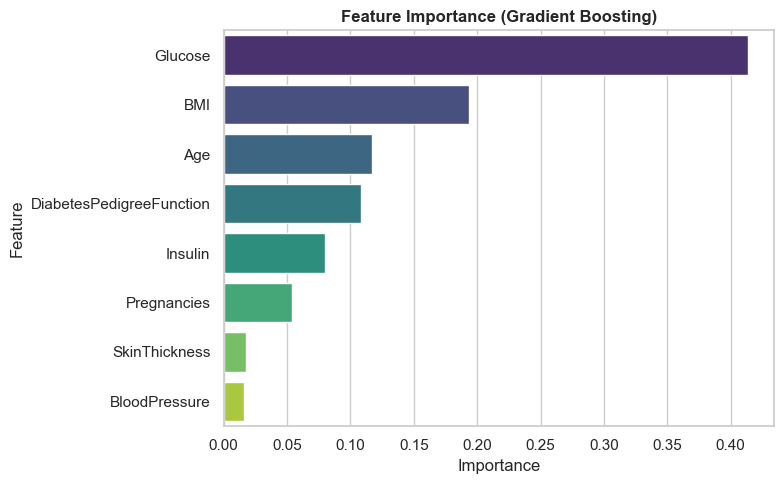

In [14]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

if importances is not None:
    imp_df = pd.DataFrame({"Feature": X.columns, "Importance": importances}).sort_values("Importance", ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=imp_df, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
    plt.title(f"Feature Importance ({best_name})", fontweight="bold")
    plt.tight_layout()
    plt.show()


## 6. Save the model for the web app

In [15]:
import json

joblib.dump(best_model, "../models/diabetes_model.joblib")
joblib.dump(scaler, "../models/diabetes_scaler.joblib")
with open("../models/diabetes_metadata.json", "w") as f:
    json.dump({
        "disease": "Diabetes",
        "best_model": best_name,
        "metrics": results_df.iloc[0].to_dict(),
        "class_names": ["No Diabetes", "Diabetes"],
        "feature_names": list(X.columns),
    }, f, indent=2)

print("Saved model, scaler, and metadata to ../models/")


Saved model, scaler, and metadata to ../models/


In [16]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Train the clean, 8-feature champion model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# 2. Save it right over the old files
joblib.dump(rf_classifier, 'diabetes_model.joblib')
joblib.dump(scaler, 'diabetes_scaler.joblib')

['diabetes_scaler.joblib']


## Conclusion & next steps

- We cleaned the raw data, explored it visually, and trained **six different algorithms** under identical, fair conditions.
- **the best-performing model (see results table above)** came out on top for this dataset, balancing accuracy, recall, and ROC-AUC.
- The trained model + scaler have been saved to `models/diabetes_model.joblib` and `models/diabetes_scaler.joblib`, ready to be loaded by the Streamlit web app (`app/app.py`).

### Ideas to extend this project further
- Try hyperparameter tuning with `GridSearchCV` or `RandomizedSearchCV` to squeeze out more performance.
- Try `SMOTE` (from the `imbalanced-learn` library) if you want to address class imbalance more aggressively.
- Collect a larger, more diverse dataset — small datasets like this one risk overfitting to quirks of the sample.
- Add SHAP value explanations so the model can justify *why* it made a particular prediction (very important for medical trust).

> ⚠️ **Disclaimer:** This model is an educational/portfolio project, not a certified medical device. It should never be used for real clinical decision-making without rigorous validation, regulatory approval, and physician oversight.


In [17]:
import os
print(os.getcwd())

C:\Users\PRABHLEEN KAUR\Downloads\disease-prediction\notebooks
